In [24]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

# === Data Preprocessing ===
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


# === Train/Test Splits & Cross-Validation ===
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_predict, cross_val_score,
    GridSearchCV, RandomizedSearchCV, ParameterGrid
)

# === Metrics & Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)

from sklearn.decomposition import PCA
# === Pipelines ===
from sklearn.pipeline import make_pipeline

# === Machine Learning Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

In [25]:
from training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [26]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [32]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)
# file_path = '/Users/kittnguyen/Documents/us-flight-project/data/deep_learning_data/'
# X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
# y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
# X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
# y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
# X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
# y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# XGBoost

## a. Training

In [33]:
# --- XGBoost Classifier ---
xgb_model = XGBClassifier(
    n_estimators=500,          # số cây (boosting rounds)
    learning_rate=0.05,        # tốc độ học, nhỏ để tránh overfit
    max_depth=7,               # độ sâu cây
    subsample=0.8,             # lấy 80% dữ liệu mỗi vòng boosting
    colsample_bytree=0.8,      # lấy 80% feature mỗi cây
    min_child_weight=5,        # kiểm soát overfitting
    reg_lambda=1.0,            # L2 regularization
    reg_alpha=0.0,             # L1 regularization
    scale_pos_weight=1,        
    tree_method="hist",        # tối ưu tốc độ trên tập lớn
    random_state=42,
    n_jobs=-1,
)

# --- Training ---
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Predicting & Evaluating

### Dev

Evaluation on  set:
Accuracy : 0.6976
Precision: 0.6545
Recall   : 0.4279
F1-score : 0.5175
ROC AUC  : 0.7285


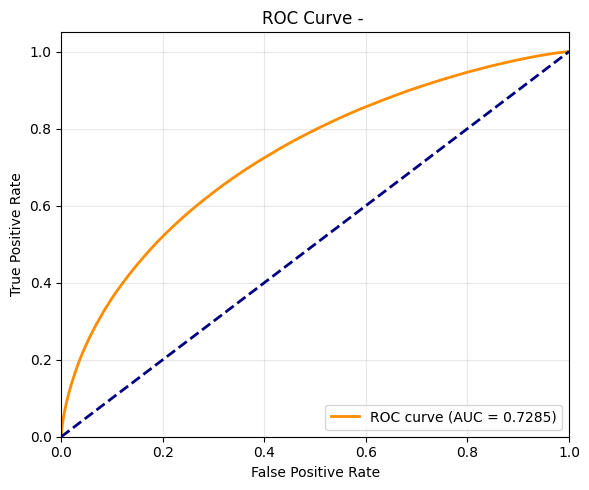

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78    837529
           1       0.65      0.43      0.52    511152

    accuracy                           0.70   1348681
   macro avg       0.68      0.65      0.65   1348681
weighted avg       0.69      0.70      0.68   1348681



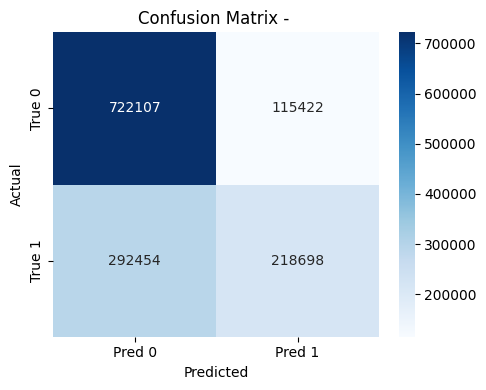

Best threshold: 0.50 with F1-score: 1.0000


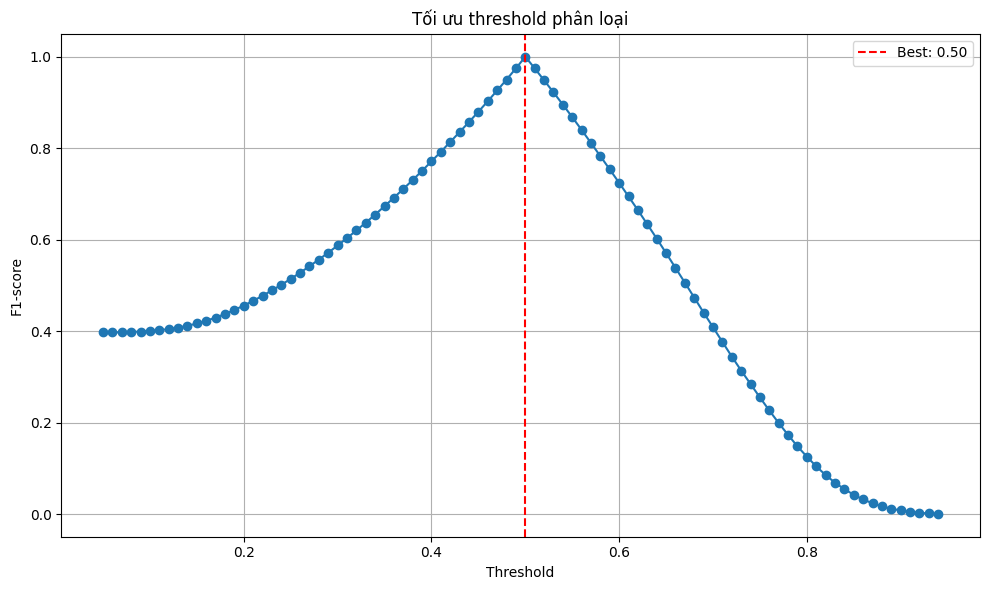

(np.float64(0.5000000000000001), 1.0)

In [34]:
# --- Predicting ---
y_pred_dev = xgb_model.predict(X_dev)
y_proba_dev = xgb_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (xgb_model, X_dev, y_pred_dev)

### Test

Evaluation on  set:
Accuracy : 0.6981
Precision: 0.6554
Recall   : 0.429
F1-score : 0.5186
ROC AUC  : 0.7292


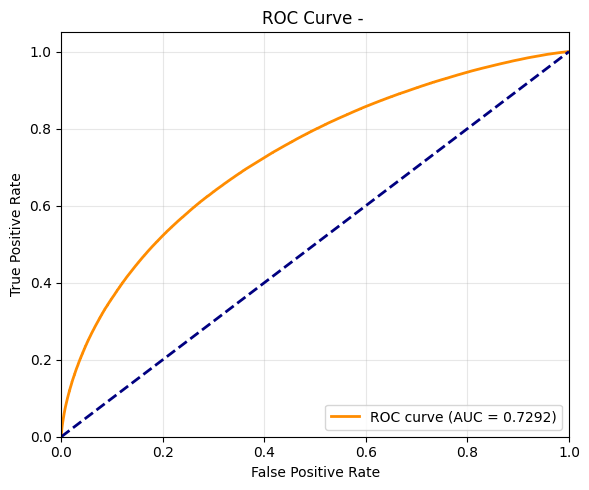

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78    837529
           1       0.66      0.43      0.52    511152

    accuracy                           0.70   1348681
   macro avg       0.68      0.65      0.65   1348681
weighted avg       0.69      0.70      0.68   1348681



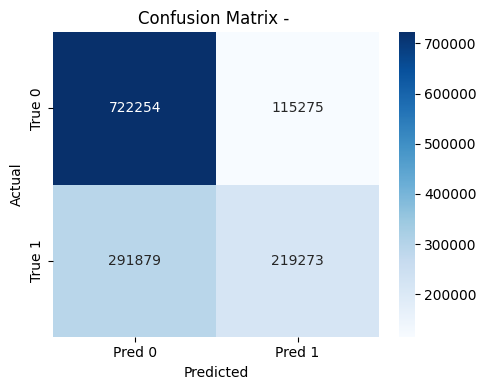

Best threshold: 0.50 with F1-score: 1.0000


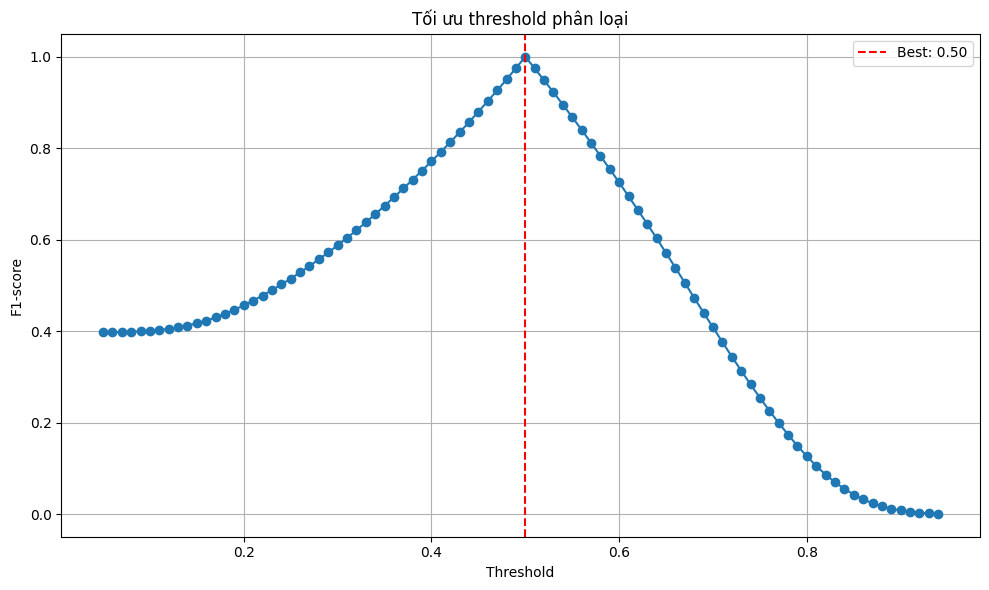

(np.float64(0.5000000000000001), 1.0)

In [23]:
# --- Predicting ---
y_pred_test = xgb_model.predict(X_test)
y_proba_test = xgb_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (xgb_model, X_test, y_pred_test)